In [1]:
import datetime
from concordia.agents import entity_agent
from concordia.agents import entity_agent_with_logging 
from concordia.associative_memory import basic_associative_memory
from concordia.components import agent as agent_components
from concordia.components.agent import concat_act_component
from concordia.contrib import language_models as language_model_utils
from concordia.contrib.language_models.ollama import ollama_model
from concordia.environment.engines import asynchronous
from concordia.prefabs.simulation import generic as simulation
import concordia.prefabs.game_master as game_master_prefabs
import concordia.prefabs.entity as entity_prefabs
from concordia.typing import prefab as prefab_lib
from concordia.utils import async_measurements as async_measurements_lib
from concordia.utils import helper_functions
import pandas as pd
from IPython import display
import numpy as np
from numpy.linalg import norm
import sentence_transformers
import ollama
import json
import os
import yaml
import random
import itertools
import time
import logging

In [2]:
os.environ["OLLAMA_HOST"] = "http://localhost:11434"

model = ollama_model.OllamaLanguageModel(
    model_name="deepseek-r1:8b",
)

In [3]:
with open('personas.yaml', 'r', encoding='utf-8') as f:
    yaml_data = yaml.safe_load(f)['personas']

In [4]:
class MpnetEmbedder:
    """Embedder using HuggingFace, adpted to Concordia."""
    
    def __init__(self, model):
        self._model = model
    def __call__(self, text: str) -> np.ndarray:
        return self._model.encode(text, show_progress_bar=False).astype(np.float32)
    def embed(self, text: str) -> np.ndarray:
        return self._model.encode(text, show_progress_bar=False).astype(np.float32)

    def embed_sentence(self, text: str) -> np.ndarray:
        return self.embed(text)

In [5]:
st_model = sentence_transformers.SentenceTransformer('sentence-transformers/all-mpnet-base-v2')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [6]:
embedder = MpnetEmbedder(st_model)

In [7]:
def load_mapping():
    with open("mfq_mapping.json") as f:
        mapping = json.load(f)

    return mapping

In [8]:
def analyze_results(results, mapping):

    analysis = []

    for r in results:

        scores = compute_mfq_scores(
            r["answers"],
            mapping
        )

        analysis.append({
            "persona": r["persona"],
            **scores
        })

    return analysis

In [9]:
def compute_mfq_scores(answers, mapping):

    scores = {}

    for foundation, questions in mapping.items():

        values = [] 

        for q in questions:
            if q in answers:
                values.append(answers[q])

        scores[foundation] = np.mean(values)

    return scores

In [10]:
with open("results.json", "r", encoding="utf-8") as f:
    json_results = json.load(f)

mapping = load_mapping()

analysis = analyze_results(json_results, mapping)

df_mft = pd.DataFrame(analysis)

df_mft = df_mft.dropna(subset=['care', 'fairness', 'loyalty', 'authority', 'purity'])

In [11]:
def build_concordia_agent(persona_yaml, mft_scores, current_news):
    name = persona_yaml['name']

    interests = "\n- ".join(persona_yaml['interests'])
    beliefs = "\n- ".join(persona_yaml['beliefs'])

    identity_prompt = f"""
You are {name}, {persona_yaml['age_range']} years old, from {persona_yaml['location']}.
Occupation: {persona_yaml['occupation']}
Description: {persona_yaml['small_description']}

Your main interests:
- {interests}

Your core beliefs:
- {beliefs}

Your Moral Foundations (0-5, higher = more important to you):
- Care/Harm: {mft_scores['care']:.2f}
- Fairness/Cheating: {mft_scores['fairness']:.2f}
- Loyalty/Betrayal: {mft_scores['loyalty']:.2f}
- Authority/Subversion: {mft_scores['authority']:.2f}
- Purity/Degradation: {mft_scores['purity']:.2f}

You are reading a news/political discussion forum. The trending topic
(already pinned as Post #0 in your feed) is:
"{current_news}"

How to act each turn (pick ONE action):

1) Read each visible post/reply and judge YOUR stance toward that item:
   - strong agreement (you would endorse it in public),
   - mild/neutral (tolerable but not something you champion),
   - disagreement (wrong, biased, or misaligned with you),
   - strong disagreement (attacks your core beliefs or deeply offends foundations
     that matter to you on the scale above).

2) Pick EXACTLY ONE action that matches that stance. Do not use share or upvote
   to "stay active" or be polite.

   - share    : VERY RARE. ONLY if you STRONGLY agree with the TOP-LEVEL post AND
                actively want it spread widely (unprompted recommendation).
                Never share when you disagree, feel mixed, are neutral, or only
                mildly agree. Never share just because it is news or trending—
                sharing is public amplification, like endorsing a headline.
                (Only top-level posts can be shared.)

   - upvote   : ONLY if you clearly agree with THAT specific post or reply.
                If you disagree or oppose it, you must NOT upvote.

   - downvote : Use when the item clashes with your core beliefs above and/or
                violates a moral foundation that is important TO YOU (pay more
                attention to foundations where your score is higher). Prefer
                downvote for principled offense, not for boredom.

   - reply    : Use when you STRONGLY disagree and want to contest, correct, warn,
                or debate in public—especially when a downvote alone would hide
                your reasoning. Mild disagreement can be ignore or a short reply;
                sharp disagreement should be reply (you may downvote on a later
                turn if the platform still allows it).

   - post     : ONLY if you have a genuinely new angle the thread does not cover.

   - ignore   : You are disinterested or choose not to engage.

If you OPPOSE the content: NEVER share and NEVER upvote. Prefer downvote when
principles are at stake; prefer reply when your disagreement is intense.

Output rules:
- Output EXACTLY ONE valid JSON object. No markdown fences, no prose.
- Use only ids that appear in your current feed. Never invent ids.
- Post ids and reply ids share the SAME number space; both appear in the
  visible ids list. Pass either one as the "post_id" field for upvote,
  downvote, and reply.
- share only works on top-level posts. Sharing a reply will be rejected.
- Stay on the trending topic. Do not talk about your daily routine.
- You can share each post only once. Do not share the same post again later.
- You can vote on each post or reply only once total: pick upvote OR downvote
  one time; do not vote on the same id again afterwards.
- If you already shared or voted on something, choose another action (reply,
  post) or ignore. Repeating a share or vote on the same id will be silently
  treated as ignore.

Action shapes:
{{"action": "share", "author": "{name}", "post_id": "<id>"}}
{{"action": "upvote", "author": "{name}", "post_id": "<id>"}}
{{"action": "downvote", "author": "{name}", "post_id": "<id>"}}
{{"action": "reply", "author": "{name}", "post_id": "<id>", "content": "..."}}
{{"action": "post", "author": "{name}", "title": "...", "content": "..."}}
{{"action": "ignore", "author": "{name}"}}
"""

    raw_memory_list = []
    memory = agent_components.memory.ListMemory(memory_bank=raw_memory_list)

    identity = agent_components.constant.Constant(state=identity_prompt)

    act_comp = concat_act_component.ConcatActComponent(model=model)

    agent = entity_agent_with_logging.EntityAgentWithLogging(
        agent_name=name,
        act_component=act_comp,
        context_components={
            'memory': memory,
            'identity': identity
        },
        measurements=async_measurements_lib.ReactiveMeasurements()
    )
    return agent


FORUM_CALL_TO_ACTION = (
    game_master_prefabs.async_social_media.DEFAULT_CALL_TO_ACTION
    + "\n\nStrict engagement policy (mandatory):\n"
    "- share: ONLY if you STRONGLY endorse the post and actively want it spread; "
    "never for politeness, visibility, mild agreement, neutrality, or disagreement.\n"
    "- upvote: ONLY for clear agreement with that exact item; never when you "
    "disagree or oppose it.\n"
    "- downvote: when the item conflicts with your core beliefs or offends a "
    "foundation that matters to you (weight higher foundations more).\n"
    "- reply: when you STRONGLY disagree and want to contest in public; use this "
    "instead of silent agreement signals.\n"
    "- If you oppose the content: NEVER share or upvote; use downvote and/or reply, "
    "or ignore.\n"
)

In [12]:
num_batches = 10
batch_size = 5
max_steps = 10

MFT_KEYS = ['care', 'fairness', 'loyalty', 'authority', 'purity']

# Each topic carries a hand-coded MFT profile (0-5 scale) describing which
# foundations the news activates. Used later to compute moral resonance
# between the news and each persona.
NEWS_TOPICS = [
    {
        'id': 'hospital_donation',
        'title': "Children's Hospital Receives Record Donation and Expands Treatment for Rare Diseases",
        'body': "A nationwide campaign raised millions for a children's hospital, allowing the opening of new wings and free treatment for hundreds of vulnerable children.",
        'topic_mft': {'care': 5.0, 'fairness': 4.0, 'loyalty': 3.0, 'authority': 2.0, 'purity': 2.0},
    },
    {
        'id': 'congress_corruption',
        'title': "Congressman Uses Public Funds for Personal Trip and Faces Investigation",
        'body': "Documents indicate that resources allocated to the congressional office were used for personal expenses abroad.",
        'topic_mft': {'care': 2.0, 'fairness': 5.0, 'loyalty': 2.0, 'authority': 4.0, 'purity': 3.0},
    },
    {
        'id': 'school_anthem',
        'title': "School Reintroduces Daily National Anthem and Stricter Discipline Rules",
        'body': "The administration states that the measure aims to reinforce respect, order, and civic values among students.",
        'topic_mft': {'care': 1.0, 'fairness': 2.0, 'loyalty': 5.0, 'authority': 5.0, 'purity': 3.0},
    },
    {
        'id': 'religious_marriage',
        'title': "Religious Leader Criticizes School Campaign Supporting Same-Sex Marriage",
        'body': "During a public event, a religious leader stated that schools should prioritize academic content and preserve traditional family values.",
        'topic_mft': {'care': 2.0, 'fairness': 3.0, 'loyalty': 4.0, 'authority': 5.0, 'purity': 5.0},
    },
    {
        'id': 'drought_climate',
        'title': "Historic Drought Forces City to Ration Water and Suspend Classes",
        'body': "Reservoirs reached critical levels after months without rain. Experts linked the extreme conditions to the advance of climate change.",
        'topic_mft': {'care': 5.0, 'fairness': 4.0, 'loyalty': 2.0, 'authority': 2.0, 'purity': 3.0},
    },
    {
        'id': 'gun_law',
        'title': "Congress Approves Bill Tightening Rules for Gun Purchase and Ownership",
        'body': "Lawmakers approved new requirements for firearms acquisition, including training, psychological evaluations, and tracking measures. Supporters argue the policy could reduce deaths and accidents.",
        'topic_mft': {'care': 4.0, 'fairness': 4.0, 'loyalty': 3.0, 'authority': 4.0, 'purity': 2.0},
    },
]

# TCC §3.2: three forum titles (neutral / conservative / progressive).
# forum_mft is the moral profile each name signals to the agents.
FORUM_VARIANTS = [
    {'name': 'Rural News',        'forum_mft': {'care': 3.0, 'fairness': 3.0, 'loyalty': 3.0, 'authority': 3.0, 'purity': 3.0}},
    {'name': 'Voz Conservadora',  'forum_mft': {'care': 3.0, 'fairness': 3.0, 'loyalty': 4.5, 'authority': 4.5, 'purity': 4.5}},
    {'name': 'Voz Progressista',  'forum_mft': {'care': 4.5, 'fairness': 4.5, 'loyalty': 2.0, 'authority': 2.0, 'purity': 2.0}},
]

print(f"\nIniciando bateria de {num_batches} experimentos aleatórios (max_steps={max_steps})...")

base_dir = r"D:\breno\Documents\TCC\Resultados"
os.makedirs(base_dir, exist_ok=True)

current_folders = [f for f in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, f)) and f.startswith("Experimento ")]
next_num = 8
if current_folders:
    numbers = []
    for folder in current_folders:
        try:
            numbers.append(int(folder.replace("Experimento -", "")))
        except ValueError:
            pass
    if numbers:
        next_num = max(max(numbers) + 1, 8)

new_folder = os.path.join(base_dir, f"Experimento - {next_num}")
os.makedirs(new_folder, exist_ok=True)
runs_folder = os.path.join(new_folder, 'runs')
os.makedirs(runs_folder, exist_ok=True)

run_id = datetime.datetime.now().strftime('%Y%m%d-%H%M%S')
all_actions_path = os.path.join(new_folder, 'all_actions.jsonl')
metadata_path = os.path.join(new_folder, 'metadata.json')
if os.path.exists(all_actions_path):
    os.remove(all_actions_path)

batch_metadata = {
    'run_id': run_id,
    'created_at': datetime.datetime.now().isoformat(),
    'num_batches': num_batches,
    'batch_size': batch_size,
    'max_steps': max_steps,
    'model_name': getattr(model, 'model_name', 'deepseek-r1:8b'),
    'results_folder': new_folder,
    'runs_folder': runs_folder,
    'all_actions_path': all_actions_path,
    'news_topics': NEWS_TOPICS,
    'forum_variants': FORUM_VARIANTS,
}
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(batch_metadata, f, ensure_ascii=False, indent=2)

print(f"\n📂 Diretório criado para salvar resultados: {new_folder}")
print(f"[RUN ID]: {run_id}")


def _mft_dict_to_vec(d):
    return np.array([float(d[k]) for k in MFT_KEYS], dtype=np.float64)


def _cos_sim(v1, v2):
    n1, n2 = norm(v1), norm(v2)
    if n1 == 0 or n2 == 0:
        return float('nan')
    return float(np.dot(v1, v2) / (n1 * n2))


def compute_summary(action_rows, forum_state, persona_mft_by_name, news_topic, forum_variant, group_mean_mft, group_similarity):
    """Compute diffusion metrics from the append-only action registry."""
    state = forum_state.get_state()
    posts = sorted(state['posts'].values(), key=lambda p: p['post_id'])
    if not posts:
        return {}

    seed = posts[0]
    derived = posts[1:]
    successful = [a for a in action_rows if a.get('status') == 'success']

    seed_actions = [a for a in successful if a.get('target_post_id') == 0]
    seed_replies = [a for a in seed_actions if a.get('action_type') == 'reply']
    seed_upvotes = [a for a in seed_actions if a.get('action_type') == 'upvote']
    seed_downvotes = [a for a in seed_actions if a.get('action_type') == 'downvote']
    seed_shares = [a for a in seed_actions if a.get('action_type') == 'share']

    seed_post = {
        'post_id': seed['post_id'],
        'author': seed['author'],
        'upvotes': len(seed_upvotes),
        'downvotes': len(seed_downvotes),
        'votes': len(seed_upvotes) - len(seed_downvotes),
        'shares': len(seed_shares),
        'reply_count': len(seed_replies),
        'unique_repliers': sorted({a['actor'] for a in seed_replies}),
        'unique_sharers': sorted({a['actor'] for a in seed_shares}),
    }

    status_counts = {}
    action_type_counts = {}
    for a in action_rows:
        status_counts[a.get('status', 'unknown')] = status_counts.get(a.get('status', 'unknown'), 0) + 1
        action_type_counts[a.get('action_type', 'unknown')] = action_type_counts.get(a.get('action_type', 'unknown'), 0) + 1

    # Derived engagement is action-level, not counter-level: successful actions
    # targeting non-seed posts plus successful new posts.
    derived_engagement_rows = [
        a for a in successful
        if (a.get('target_post_id') is not None and a.get('target_post_id') != 0)
        or (a.get('action_type') == 'post' and a.get('created_post_id') not in (None, 0))
    ]

    cascade_depth = 0
    if seed_actions:
        cascade_depth = 1
    if derived_engagement_rows:
        cascade_depth = 2

    actions_per_persona = {name: {'post': 0, 'reply': 0, 'share': 0,
                                   'upvote': 0, 'downvote': 0, 'ignore': 0,
                                   'duplicate_share': 0, 'duplicate_vote': 0,
                                   'reply_upvote': 0, 'reply_downvote': 0,
                                   'quote_reply': 0,
                                   'failed': 0}
                            for name in persona_mft_by_name}
    for a in action_rows:
        actor = a.get('actor')
        if actor not in actions_per_persona:
            continue
        effective = a.get('effective_action_type') or a.get('action_type')
        attempted = a.get('attempted_action_type') or a.get('action_type')
        counts_as_ignore = bool(a.get('counts_as_ignore'))
        duplicate = bool(a.get('duplicate_interaction'))
        target_kind = a.get('target_node_kind')
        if counts_as_ignore:
            actions_per_persona[actor]['ignore'] += 1
            if duplicate and attempted == 'share':
                actions_per_persona[actor]['duplicate_share'] += 1
            elif duplicate and attempted in ('upvote', 'downvote'):
                actions_per_persona[actor]['duplicate_vote'] += 1
            continue
        if a.get('status') == 'success' and effective in actions_per_persona[actor]:
            actions_per_persona[actor][effective] += 1
            if target_kind == 'reply':
                if effective == 'upvote':
                    actions_per_persona[actor]['reply_upvote'] += 1
                elif effective == 'downvote':
                    actions_per_persona[actor]['reply_downvote'] += 1
                elif effective == 'reply':
                    actions_per_persona[actor]['quote_reply'] += 1
        elif a.get('status') != 'success':
            actions_per_persona[actor]['failed'] += 1

    unique_engagers = sorted({
        a.get('actor') for a in successful
        if a.get('actor') in persona_mft_by_name
        and (a.get('effective_action_type') or a.get('action_type')) != 'ignore'
        and not a.get('counts_as_ignore')
    })

    duplicate_share_attempts = sum(
        1 for a in action_rows
        if a.get('duplicate_interaction')
        and (a.get('attempted_action_type') == 'share')
    )
    duplicate_vote_attempts = sum(
        1 for a in action_rows
        if a.get('duplicate_interaction')
        and a.get('attempted_action_type') in ('upvote', 'downvote')
    )
    counts_as_ignore_total = sum(
        1 for a in action_rows if a.get('counts_as_ignore')
    )
    consecutive_all_ignore_cycles_final = (
        forum_state.get_consecutive_all_ignore_cycles()
    )
    ignore_cycle_threshold = forum_state.get_ignore_cycle_threshold()
    terminated_by_ignore_cycles = (
        consecutive_all_ignore_cycles_final >= ignore_cycle_threshold
    )

    seed_thread_engagement_rows = [
        a for a in successful
        if a.get('target_root_post_id') == 0
        and (a.get('effective_action_type') or a.get('action_type')) != 'ignore'
        and not a.get('counts_as_ignore')
    ]
    reply_target_rows = [
        a for a in successful if a.get('target_node_kind') == 'reply'
    ]
    reply_vote_total = sum(
        1 for a in reply_target_rows
        if (a.get('effective_action_type') or a.get('action_type'))
        in ('upvote', 'downvote')
    )
    quote_reply_total = sum(
        1 for a in reply_target_rows
        if (a.get('effective_action_type') or a.get('action_type')) == 'reply'
    )
    not_shareable_attempts = sum(
        1 for a in action_rows if a.get('status') == 'not_shareable'
    )

    topic_vec = _mft_dict_to_vec(news_topic['topic_mft'])
    forum_vec = _mft_dict_to_vec(forum_variant['forum_mft'])

    persona_resonance = {}
    for name, vec in persona_mft_by_name.items():
        persona_resonance[name] = {
            'mft_vector': vec.tolist(),
            'topic_resonance': _cos_sim(vec, topic_vec),
            'forum_alignment': _cos_sim(vec, forum_vec),
            'actions': actions_per_persona[name],
        }

    return {
        'news_topic_id': news_topic['id'],
        'news_title': news_topic['title'],
        'topic_mft': news_topic['topic_mft'],
        'forum_variant': forum_variant['name'],
        'forum_mft': forum_variant['forum_mft'],
        'group_mean_mft': dict(zip(MFT_KEYS, [float(x) for x in group_mean_mft])),
        'group_cosine_similarity_pct': float(group_similarity),
        'seed_post': seed_post,
        'derived_post_count': len(derived),
        'derived_engagement_total': len(derived_engagement_rows),
        'cascade_depth': cascade_depth,
        'unique_engagers': unique_engagers,
        'unique_engagers_count': len(unique_engagers),
        'status_counts': status_counts,
        'action_type_counts': action_type_counts,
        'duplicate_share_attempts': duplicate_share_attempts,
        'duplicate_vote_attempts': duplicate_vote_attempts,
        'counts_as_ignore_total': counts_as_ignore_total,
        'consecutive_all_ignore_cycles_final': consecutive_all_ignore_cycles_final,
        'ignore_cycle_threshold': ignore_cycle_threshold,
        'terminated_by_ignore_cycles': terminated_by_ignore_cycles,
        'seed_thread_engagement_total': len(seed_thread_engagement_rows),
        'reply_vote_total': reply_vote_total,
        'quote_reply_total': quote_reply_total,
        'not_shareable_attempts': not_shareable_attempts,
        'persona_resonance': persona_resonance,
    }


persona_list = []
full_start_time = time.time()

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s %(levelname)s [%(name)s] %(message)s',
    force=True,
)

for batch_index in range(num_batches):
    print(f"\n{'='*60}")
    print(f" EXPERIMENTO {batch_index + 1} DE {num_batches} ")
    print(f"{'='*60}")
    batch_start_time = time.time()
    _perf_t0 = time.perf_counter()

    news_topic = NEWS_TOPICS[batch_index % len(NEWS_TOPICS)]
    forum_variant = random.choice(FORUM_VARIANTS)
    forum_name = f"{forum_variant['name']} (Exp {batch_index + 1})"

    # Plain-text version used inside the persona prompt.
    current_news = f"{news_topic['title']} — {news_topic['body']}"

    print(f"\n[TEMA]: {news_topic['title']}")
    print(f"[FÓRUM]: {forum_name}")

    if len(persona_list) < batch_size:
        print("\n[SISTEMA] Embaralhando as 40 personas para garantir participação de todos...")
        persona_list = list(yaml_data)
        random.shuffle(persona_list)

    batch_group = persona_list[:batch_size]
    persona_list = persona_list[batch_size:]

    print("\n--- COMPOSIÇÃO DO GRUPO ---")
    active_agents = []
    vetores_mft_do_grupo = []
    persona_mft_by_name = {}
    persona_metadata = {}

    for persona_yaml in batch_group:
        name = persona_yaml['name']
        mft_row = df_mft[df_mft['persona'] == name]
        if mft_row.empty:
            print(f" -> AVISO: Dados de MFT não encontrados para {name}")
            continue
        mft_scores = mft_row.iloc[0]
        vetor_mft = mft_scores[MFT_KEYS].astype(float).values
        vetores_mft_do_grupo.append(vetor_mft)
        persona_mft_by_name[name] = vetor_mft
        persona_metadata[name] = {
            'actor_mft_care': float(vetor_mft[0]),
            'actor_mft_fairness': float(vetor_mft[1]),
            'actor_mft_loyalty': float(vetor_mft[2]),
            'actor_mft_authority': float(vetor_mft[3]),
            'actor_mft_purity': float(vetor_mft[4]),
            'actor_occupation': persona_yaml.get('occupation', ''),
            'actor_location': persona_yaml.get('location', ''),
            'actor_age_range': persona_yaml.get('age_range', ''),
        }
        print(f" -> {name:<25} | Vetor: [{', '.join(f'{v:.1f}' for v in vetor_mft)}]")
        active_agents.append(build_concordia_agent(persona_yaml, mft_scores, current_news))

    medias_grupo = np.zeros(len(MFT_KEYS))
    porcentagem_sim = float('nan')
    if len(vetores_mft_do_grupo) > 1:
        matriz_mft = np.array(vetores_mft_do_grupo)
        medias_grupo = np.mean(matriz_mft, axis=0)
        print("\n--- MÉDIA MORAL DO GRUPO (PERFIL DO FÓRUM) ---")
        print(f"Care: {medias_grupo[0]:.2f} | Fairness: {medias_grupo[1]:.2f} | "
              f"Loyalty: {medias_grupo[2]:.2f} | Authority: {medias_grupo[3]:.2f} | "
              f"Purity: {medias_grupo[4]:.2f}")

        sims = [_cos_sim(v1, v2) for v1, v2 in itertools.combinations(matriz_mft, 2)]
        sims = [s for s in sims if not np.isnan(s)]
        if sims:
            porcentagem_sim = float(np.mean(sims) * 100)
            tag = ""
            if porcentagem_sim > 94:
                tag = "  (Forte Bolha Ideológica)"
            elif porcentagem_sim < 82:
                tag = "  (Fórum Polarizado)"
            print(f"\n[MÉTRICA] Similaridade Vetorial do Grupo: {porcentagem_sim:.1f}%{tag}")

    print("\n--- INICIANDO FÓRUM ASSÍNCRONO ---")
    _perf_t1 = time.perf_counter()

    gm_memory_bank = basic_associative_memory.AssociativeMemoryBank(
        sentence_embedder=embedder
    )

    gm_prefab = game_master_prefabs.async_social_media.GameMaster(
        entities=active_agents,
        params={
            'name': 'forum_rules',
            'forum_name': forum_name,
            'call_to_action': FORUM_CALL_TO_ACTION,
            'seed_posts': [{
                'author': 'BREAKING NEWS',
                'title': news_topic['title'],
                'content': news_topic['body'],
            }],
            'ignore_cycle_threshold': 3,
            'measurements': async_measurements_lib.ReactiveMeasurements(),
        },
    )
    gm = gm_prefab.build(model=model, memory_bank=gm_memory_bank)
    _perf_t2 = time.perf_counter()

    sim_engine = asynchronous.Asynchronous()
    sim_engine.run_loop(
        game_masters=[gm],
        entities=active_agents,
        premise='',
        max_steps=max_steps,
        verbose=True,
    )
    _perf_t3 = time.perf_counter()

    print(f"\n--- FIM DO EXPERIMENTO {batch_index + 1} ---")

    forum_state = gm.get_component('__forum__')
    experiment_index = batch_index + 1
    run_prefix = f"run-{experiment_index:03d}"
    experiment_metadata = {
        'run_id': run_id,
        'experiment_index': experiment_index,
        'forum_name': forum_name,
        'forum_variant': forum_variant['name'],
        'news_topic_id': news_topic['id'],
        'news_title': news_topic['title'],
        'max_steps': max_steps,
        'batch_size': batch_size,
        'group_cosine_similarity_pct': porcentagem_sim,
    }

    actions_path = os.path.join(runs_folder, f"{run_prefix}-actions.jsonl")
    n_actions = forum_state.to_action_jsonl(
        actions_path,
        experiment_metadata=experiment_metadata,
        persona_metadata=persona_metadata,
    )
    forum_state.to_action_jsonl(
        all_actions_path,
        experiment_metadata=experiment_metadata,
        persona_metadata=persona_metadata,
        append=True,
    )
    action_rows = forum_state.get_action_log()
    print(f"💾 {n_actions} ações salvas em: {actions_path}")

    events_path = os.path.join(runs_folder, f"{run_prefix}-forum-snapshot.jsonl")
    n_events = forum_state.to_jsonl_events(events_path)
    print(f"💾 {n_events} eventos de estado salvos em: {events_path}")

    summary = compute_summary(
        action_rows=action_rows,
        forum_state=forum_state,
        persona_mft_by_name=persona_mft_by_name,
        news_topic=news_topic,
        forum_variant=forum_variant,
        group_mean_mft=medias_grupo,
        group_similarity=porcentagem_sim,
    )
    summary.update(experiment_metadata)
    summary_path = os.path.join(runs_folder, f"{run_prefix}-summary.json")
    with open(summary_path, 'w', encoding='utf-8') as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)
    print(f"💾 Sumário salvo em: {summary_path}")

    if summary:
        sp = summary['seed_post']
        print(f"\n[DIFUSÃO] Post #0 → shares={sp['shares']}, votes={sp['votes']}, "
              f"replies={sp['reply_count']}, derived_posts={summary['derived_post_count']}, "
              f"engajamento_derivado={summary['derived_engagement_total']}, "
              f"cascade_depth={summary['cascade_depth']}, "
              f"unique_engagers={summary['unique_engagers_count']}")
        print(f"[INATIVIDADE] ciclos_all_ignore={summary['consecutive_all_ignore_cycles_final']}/"
              f"{summary['ignore_cycle_threshold']} "
              f"(terminado por inatividade: {summary['terminated_by_ignore_cycles']}), "
              f"duplicates_share={summary['duplicate_share_attempts']}, "
              f"duplicates_vote={summary['duplicate_vote_attempts']}, "
              f"counts_as_ignore={summary['counts_as_ignore_total']}")
        print(f"[REPLIES] seed_thread_engagement={summary['seed_thread_engagement_total']}, "
              f"reply_votes={summary['reply_vote_total']}, "
              f"quote_replies={summary['quote_reply_total']}, "
              f"not_shareable={summary['not_shareable_attempts']}")

    _perf_t4 = time.perf_counter()
    print(
        f"\n[PERF] experimento {batch_index + 1}: "
        f"grupo+agentes={_perf_t1 - _perf_t0:.2f}s, "
        f"memória_GM+prefab+build={_perf_t2 - _perf_t1:.2f}s, "
        f"run_loop={_perf_t3 - _perf_t2:.2f}s, "
        f"export+json={_perf_t4 - _perf_t3:.2f}s, "
        f"total_cpu_phases={_perf_t4 - _perf_t0:.2f}s"
    )

    batch_end_time = time.time()
    min_b, sec_b = divmod(batch_end_time - batch_start_time, 60)
    print(f"\n[TEMPO] ⏱️ Experimento {batch_index + 1} levou {int(min_b)}m {int(sec_b)}s.")

full_end_time = time.time()
min_t, sec_t = divmod(full_end_time - full_start_time, 60)
print(f"\n{'='*60}")
print(f" SIMULAÇÃO COMPLETA FINALIZADA!")
print(f" ⏱️ Tempo total: {int(min_t)} minutos e {int(sec_t)} segundos.")
print(f" 📂 Resultados em: {new_folder}")
print(f"{'='*60}")


Iniciando bateria de 10 experimentos aleatórios (max_steps=10)...

📂 Diretório criado para salvar resultados: D:\breno\Documents\TCC\Resultados\Experimento - 52
[RUN ID]: 20260520-154802

 EXPERIMENTO 1 DE 10 

[TEMA]: Children's Hospital Receives Record Donation and Expands Treatment for Rare Diseases
[FÓRUM]: Rural News (Exp 1)

[SISTEMA] Embaralhando as 40 personas para garantir participação de todos...

--- COMPOSIÇÃO DO GRUPO ---
 -> Felipe Duarte             | Vetor: [3.5, 3.8, 3.5, 2.8, 2.0]
 -> Carlos Tavares            | Vetor: [4.2, 4.0, 4.8, 3.5, 2.8]
 -> Adriana Souza             | Vetor: [4.2, 4.0, 2.5, 2.0, 1.8]
 -> Lucas Andrade             | Vetor: [2.8, 3.5, 1.5, 0.2, 1.8]
 -> Maria Aparecida Silva     | Vetor: [4.5, 3.2, 4.2, 4.2, 4.2]

--- MÉDIA MORAL DO GRUPO (PERFIL DO FÓRUM) ---
Care: 3.83 | Fairness: 3.70 | Loyalty: 3.30 | Authority: 2.55 | Purity: 2.52

[MÉTRICA] Similaridade Vetorial do Grupo: 93.8%

--- INICIANDO FÓRUM ASSÍNCRONO ---
Terminate? No
Terminate? 

2026-05-20 15:48:02,727 INFO [concordia.contrib.components.game_master.forum] ForumObservation.pre_act MAKE_OBSERVATION: parse_call=0.000s get_forum=0.000s drain_notifications=0.000s summary_for_player=0.000s vote_summary_visible_ids=0.000s assemble_result=0.000s total=0.000s player=Felipe Duarte n_notifications=0 visible_ids=1 result_chars=522
2026-05-20 15:48:02,756 INFO [concordia.contrib.components.game_master.forum] ForumObservation.pre_act MAKE_OBSERVATION: parse_call=0.000s get_forum=0.000s drain_notifications=0.000s summary_for_player=0.000s vote_summary_visible_ids=0.000s assemble_result=0.000s total=0.000s player=Carlos Tavares n_notifications=0 visible_ids=1 result_chars=522
2026-05-20 15:48:02,861 INFO [concordia.contrib.components.game_master.forum] ForumObservation.pre_act MAKE_OBSERVATION: parse_call=0.000s get_forum=0.000s drain_notifications=0.000s summary_for_player=0.000s vote_summary_visible_ids=0.000s assemble_result=0.000s total=0.000s player=Adriana Souza n_notif

Entity Felipe Duarte observed: [Post #0] "Children's Hospital Receives Record Donation and Expands Treatment for Rare Diseases" by BREAKING NEWS (votes: 0, replies: 0, shares: 0)
  A nationwide campaign raised millions for a children's hospital, allowing the opening of new wings and free treatment for hundreds of vulnerable children.


Rural News (Exp 1) vote counts: Post #0: 0 votes


Visible ids you may interact with (posts and replies): [0]. Do NOT invent ids that are not in this list. Note: share only works on top-level posts (not on replies).
Entity Felipe Duarte is next to act. They must respond in the format: "ActionSpec(call_to_action='What does {name} do on the forum? Respond with EXACTLY ONE valid JSON object (no markdown fences, no prose) using one of these shapes:\n{{"action": "share",    "author": "{name}", "post_id": "<post id only>"}}\n{{"action": "upvote",   "author": "{name}", "post_id": "<post or reply id>"}}\n{{"action": "downvote", "author": "{name}", "post_id": "<p

2026-05-20 15:48:02,985 INFO [concordia.contrib.components.game_master.forum] ForumObservation.pre_act MAKE_OBSERVATION: parse_call=0.000s get_forum=0.000s drain_notifications=0.000s summary_for_player=0.000s vote_summary_visible_ids=0.000s assemble_result=0.000s total=0.000s player=Maria Aparecida Silva n_notifications=0 visible_ids=1 result_chars=522


Entity Lucas Andrade observed: [Post #0] "Children's Hospital Receives Record Donation and Expands Treatment for Rare Diseases" by BREAKING NEWS (votes: 0, replies: 0, shares: 0)
  A nationwide campaign raised millions for a children's hospital, allowing the opening of new wings and free treatment for hundreds of vulnerable children.


Rural News (Exp 1) vote counts: Post #0: 0 votes


Visible ids you may interact with (posts and replies): [0]. Do NOT invent ids that are not in this list. Note: share only works on top-level posts (not on replies).
Entity Lucas Andrade is next to act. They must respond in the format: "ActionSpec(call_to_action='What does {name} do on the forum? Respond with EXACTLY ONE valid JSON object (no markdown fences, no prose) using one of these shapes:\n{{"action": "share",    "author": "{name}", "post_id": "<post id only>"}}\n{{"action": "upvote",   "author": "{name}", "post_id": "<post or reply id>"}}\n{{"action": "downvote", "author": "{name}", "post_id": "<p

2026-05-20 17:48:13,245 ERROR [absl] Error in task Lucas Andrade
Traceback (most recent call last):
  File "D:\breno\Codigos\tcc\concordia-mft\venv\Lib\site-packages\httpx\_transports\default.py", line 101, in map_httpcore_exceptions
    yield
  File "D:\breno\Codigos\tcc\concordia-mft\venv\Lib\site-packages\httpx\_transports\default.py", line 250, in handle_request
    resp = self._pool.handle_request(req)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\breno\Codigos\tcc\concordia-mft\venv\Lib\site-packages\httpcore\_sync\connection_pool.py", line 256, in handle_request
    raise exc from None
  File "D:\breno\Codigos\tcc\concordia-mft\venv\Lib\site-packages\httpcore\_sync\connection_pool.py", line 236, in handle_request
    response = connection.handle_request(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\breno\Codigos\tcc\concordia-mft\venv\Lib\site-packages\httpcore\_sync\connection.py", line 103, in handle_request
    return self._connection.handle_request(request)
  

KeyboardInterrupt: 

In [ ]:
# Aggregate action-level diffusion analysis across all experiments in `new_folder`.
# This cell treats all_actions.jsonl as the primary research dataset.

ANALYSIS_FOLDER = new_folder  # change to a fixed path to analyse a past run
all_actions_file = os.path.join(ANALYSIS_FOLDER, 'all_actions.jsonl')

if not os.path.exists(all_actions_file):
    raise FileNotFoundError(f"No action registry found at: {all_actions_file}")

df_actions = pd.read_json(all_actions_file, lines=True)
print(f"Carregadas {len(df_actions)} ações de {all_actions_file}\n")

if 'counts_as_ignore' not in df_actions.columns:
    df_actions['counts_as_ignore'] = False
if 'duplicate_interaction' not in df_actions.columns:
    df_actions['duplicate_interaction'] = False
if 'attempted_action_type' not in df_actions.columns:
    df_actions['attempted_action_type'] = df_actions['action_type']
if 'effective_action_type' not in df_actions.columns:
    df_actions['effective_action_type'] = df_actions['action_type']
if 'consecutive_all_ignore_cycles' not in df_actions.columns:
    df_actions['consecutive_all_ignore_cycles'] = 0
if 'target_node_kind' not in df_actions.columns:
    df_actions['target_node_kind'] = None
if 'target_root_post_id' not in df_actions.columns:
    df_actions['target_root_post_id'] = df_actions.get('target_post_id')
if 'parent_reply_id' not in df_actions.columns:
    df_actions['parent_reply_id'] = None
df_actions['counts_as_ignore'] = df_actions['counts_as_ignore'].fillna(False).astype(bool)
df_actions['duplicate_interaction'] = df_actions['duplicate_interaction'].fillna(False).astype(bool)
df_actions['target_root_post_id'] = df_actions['target_root_post_id'].where(
    df_actions['target_root_post_id'].notna(),
    df_actions['target_post_id'],
)

df_actions['is_success'] = df_actions['status'].eq('success')
df_actions['is_seed_action'] = df_actions['target_post_id'].eq(0)
df_actions['is_seed_thread'] = df_actions['target_root_post_id'].eq(0)
df_actions['is_reply_target'] = df_actions['target_node_kind'].eq('reply')
df_actions['is_quote_reply'] = (
    df_actions['parent_reply_id'].notna()
    & df_actions['effective_action_type'].eq('reply')
    & df_actions['is_success']
)
df_actions['is_effective_ignore'] = (
    df_actions['effective_action_type'].eq('ignore') | df_actions['counts_as_ignore']
)
df_actions['is_engagement'] = df_actions['is_success'] & ~df_actions['is_effective_ignore']
df_actions['is_real_failure'] = ~df_actions['is_success'] & ~df_actions['counts_as_ignore']


def _row_mft_vec(row):
    return np.array([
        row['actor_mft_care'],
        row['actor_mft_fairness'],
        row['actor_mft_loyalty'],
        row['actor_mft_authority'],
        row['actor_mft_purity'],
    ], dtype=np.float64)


topic_mft_by_id = {t['id']: _mft_dict_to_vec(t['topic_mft']) for t in NEWS_TOPICS}
forum_mft_by_name = {f['name']: _mft_dict_to_vec(f['forum_mft']) for f in FORUM_VARIANTS}

df_actions['topic_resonance'] = df_actions.apply(
    lambda row: _cos_sim(_row_mft_vec(row), topic_mft_by_id[row['news_topic_id']]),
    axis=1,
)
df_actions['forum_alignment'] = df_actions.apply(
    lambda row: _cos_sim(_row_mft_vec(row), forum_mft_by_name[row['forum_variant']]),
    axis=1,
)

print("=== Dataset principal ===")
display.display(df_actions.head())


print("\n=== 1) Distribuição de ações por tipo e status ===")
action_distribution = df_actions.groupby(['action_type', 'attempted_action_type', 'status']).size().reset_index(name='n')
display.display(action_distribution)

persona_action_distribution = df_actions.groupby(['actor', 'action_type', 'attempted_action_type', 'status']).size().reset_index(name='n')


print("\n=== 2) Taxa de compartilhamento por persona ===")
persona_rates = df_actions.groupby('actor').agg(
    total_actions=('action_seq', 'count'),
    successful_actions=('is_success', 'sum'),
    shares=('attempted_action_type', lambda s: (s == 'share').sum()),
    successful_shares=('attempted_action_type', lambda s: ((s == 'share') & df_actions.loc[s.index, 'is_success']).sum()),
    seed_shares=('attempted_action_type', lambda s: ((s == 'share') & df_actions.loc[s.index, 'is_success'] & df_actions.loc[s.index, 'is_seed_action']).sum()),
    replies=('attempted_action_type', lambda s: ((s == 'reply') & df_actions.loc[s.index, 'is_success']).sum()),
    posts=('attempted_action_type', lambda s: ((s == 'post') & df_actions.loc[s.index, 'is_success']).sum()),
    duplicate_share_attempts=('duplicate_interaction', lambda s: (s & df_actions.loc[s.index, 'attempted_action_type'].eq('share')).sum()),
    duplicate_vote_attempts=('duplicate_interaction', lambda s: (s & df_actions.loc[s.index, 'attempted_action_type'].isin(['upvote', 'downvote'])).sum()),
    counts_as_ignore=('counts_as_ignore', 'sum'),
    effective_ignores=('is_effective_ignore', 'sum'),
    failed_actions=('is_real_failure', 'sum'),
    avg_topic_resonance=('topic_resonance', 'mean'),
    avg_forum_alignment=('forum_alignment', 'mean'),
).reset_index()
persona_rates['share_rate'] = persona_rates['successful_shares'] / persona_rates['total_actions'].replace(0, np.nan)
persona_rates['seed_share_rate'] = persona_rates['seed_shares'] / persona_rates['total_actions'].replace(0, np.nan)
display.display(persona_rates.sort_values('successful_shares', ascending=False))


print("\n=== 3) Difusão do post-semente por tópico e fórum ===")
seed_diffusion = df_actions[df_actions['is_seed_action'] & df_actions['is_success']].groupby(
    ['news_topic_id', 'forum_variant', 'action_type']
).size().reset_index(name='n')
display.display(seed_diffusion)

seed_summary = df_actions[df_actions['is_seed_action'] & df_actions['is_success']].groupby(
    ['news_topic_id', 'forum_variant']
).agg(
    seed_actions=('action_seq', 'count'),
    seed_shares=('action_type', lambda s: (s == 'share').sum()),
    seed_replies=('action_type', lambda s: (s == 'reply').sum()),
    seed_upvotes=('action_type', lambda s: (s == 'upvote').sum()),
    seed_downvotes=('action_type', lambda s: (s == 'downvote').sum()),
    unique_engagers=('actor', 'nunique'),
).reset_index()
display.display(seed_summary)


print("\n=== 4) Taxa de erro por persona (excluindo duplicatas) ===")
error_rates = df_actions.groupby('actor').agg(
    total_actions=('action_seq', 'count'),
    failed_actions=('is_real_failure', 'sum'),
    duplicate_attempts=('duplicate_interaction', 'sum'),
).reset_index()
error_rates['error_rate'] = error_rates['failed_actions'] / error_rates['total_actions'].replace(0, np.nan)
display.display(error_rates.sort_values('error_rate', ascending=False))

status_by_topic = df_actions.groupby(['news_topic_id', 'status']).size().reset_index(name='n')


print("\n=== 4.1) Tentativas duplicadas (share/voto) por persona ===")
duplicate_breakdown = df_actions[df_actions['duplicate_interaction']].groupby(
    ['actor', 'attempted_action_type']
).size().reset_index(name='n')
display.display(duplicate_breakdown)


print("\n=== 4.2) Encerramento por inatividade (ciclos all-ignore) ===")
if 'experiment_index' in df_actions.columns:
    termination_summary = df_actions.groupby(
        ['experiment_index', 'forum_variant', 'news_topic_id']
    ).agg(
        total_actions=('action_seq', 'count'),
        counts_as_ignore_total=('counts_as_ignore', 'sum'),
        duplicate_share_attempts=('duplicate_interaction', lambda s: (s & df_actions.loc[s.index, 'attempted_action_type'].eq('share')).sum()),
        duplicate_vote_attempts=('duplicate_interaction', lambda s: (s & df_actions.loc[s.index, 'attempted_action_type'].isin(['upvote', 'downvote'])).sum()),
        consecutive_all_ignore_cycles_final=('consecutive_all_ignore_cycles', 'max'),
    ).reset_index()
    termination_summary['terminated_by_ignore_cycles'] = (
        termination_summary['consecutive_all_ignore_cycles_final'] >= 2
    )
    display.display(termination_summary)
else:
    termination_summary = pd.DataFrame()
    print("(coluna experiment_index ausente — dataset antigo)")


print("\n=== 5) Ressonância MFT vs engajamento ===")
engagement_by_actor_topic = df_actions.groupby(['actor', 'news_topic_id', 'forum_variant']).agg(
    actions=('action_seq', 'count'),
    engagements=('is_engagement', 'sum'),
    shares=('action_type', lambda s: ((s == 'share') & df_actions.loc[s.index, 'is_success']).sum()),
    topic_resonance=('topic_resonance', 'mean'),
    forum_alignment=('forum_alignment', 'mean'),
).reset_index()

corr_cols = ['topic_resonance', 'forum_alignment', 'actions', 'engagements', 'shares']
correlations = engagement_by_actor_topic[corr_cols].corr()
print("Correlação com engajamento/compartilhamento:")
display.display(correlations.loc[['topic_resonance', 'forum_alignment'], ['engagements', 'shares']].round(3))


print("\n=== 6) Compartilhamento por faixa de fundamento moral ===")
def _bin(v):
    if v < 2.5:
        return 'low'
    if v < 3.75:
        return 'mid'
    return 'high'

mft_propensity_tables = []
for foundation, column in {
    'care': 'actor_mft_care',
    'fairness': 'actor_mft_fairness',
    'loyalty': 'actor_mft_loyalty',
    'authority': 'actor_mft_authority',
    'purity': 'actor_mft_purity',
}.items():
    tmp = df_actions.copy()
    tmp[f'{foundation}_bin'] = tmp[column].map(_bin)
    table = tmp.groupby(f'{foundation}_bin').agg(
        actions=('action_seq', 'count'),
        engagements=('is_engagement', 'sum'),
        shares=('action_type', lambda s: ((s == 'share') & tmp.loc[s.index, 'is_success']).sum()),
    ).reset_index()
    table['foundation'] = foundation
    table['share_rate'] = table['shares'] / table['actions'].replace(0, np.nan)
    mft_propensity_tables.append(table)
    print(f"\n-- {foundation.upper()} --")
    display.display(table)

mft_propensity = pd.concat(mft_propensity_tables, ignore_index=True)


print("\n=== 7) Engajamento em respostas (reply-as-target) ===")
reply_actions = df_actions[df_actions['is_reply_target']]
if not reply_actions.empty:
    reply_engagement = reply_actions.groupby('actor').agg(
        reply_upvotes=('effective_action_type', lambda s: ((s == 'upvote') & reply_actions.loc[s.index, 'is_success']).sum()),
        reply_downvotes=('effective_action_type', lambda s: ((s == 'downvote') & reply_actions.loc[s.index, 'is_success']).sum()),
        quote_replies=('is_quote_reply', 'sum'),
        not_shareable_attempts=('status', lambda s: (s == 'not_shareable').sum()),
    ).reset_index()
    display.display(reply_engagement.sort_values(
        ['quote_replies', 'reply_upvotes', 'reply_downvotes'], ascending=False
    ))
else:
    reply_engagement = pd.DataFrame(
        columns=['actor', 'reply_upvotes', 'reply_downvotes', 'quote_replies',
                 'not_shareable_attempts']
    )
    print("(nenhuma ação direcionada a respostas no dataset)")


print("\n=== 8) Estrutura de threads por experimento ===")
if 'experiment_index' in df_actions.columns:
    successful_replies = df_actions[
        df_actions['is_success']
        & df_actions['effective_action_type'].eq('reply')
    ]
    thread_structure = successful_replies.groupby(
        ['experiment_index', 'forum_variant', 'news_topic_id']
    ).agg(
        total_replies=('action_seq', 'count'),
        top_level_replies=('parent_reply_id', lambda s: s.isna().sum()),
        quote_replies=('parent_reply_id', lambda s: s.notna().sum()),
        unique_repliers=('actor', 'nunique'),
    ).reset_index()
    thread_structure['quote_reply_share'] = (
        thread_structure['quote_replies']
        / thread_structure['total_replies'].replace(0, np.nan)
    )
    display.display(thread_structure)
else:
    thread_structure = pd.DataFrame()
    print("(coluna experiment_index ausente — dataset antigo)")


print("\n=== 9) Engajamento na thread do post-semente (root_post_id == 0) ===")
seed_thread_engagement = df_actions[
    df_actions['is_seed_thread']
    & df_actions['is_engagement']
].groupby(['actor', 'effective_action_type', 'target_node_kind']).size().reset_index(name='n')
display.display(seed_thread_engagement)


agg_dir = os.path.join(ANALYSIS_FOLDER, 'aggregated')
os.makedirs(agg_dir, exist_ok=True)
df_actions.to_csv(os.path.join(agg_dir, 'all_actions.csv'), index=False)
action_distribution.to_csv(os.path.join(agg_dir, 'action_distribution.csv'), index=False)
persona_action_distribution.to_csv(os.path.join(agg_dir, 'persona_action_distribution.csv'), index=False)
persona_rates.to_csv(os.path.join(agg_dir, 'persona_rates.csv'), index=False)
seed_diffusion.to_csv(os.path.join(agg_dir, 'seed_diffusion.csv'), index=False)
seed_summary.to_csv(os.path.join(agg_dir, 'seed_summary.csv'), index=False)
error_rates.to_csv(os.path.join(agg_dir, 'error_rates.csv'), index=False)
status_by_topic.to_csv(os.path.join(agg_dir, 'status_by_topic.csv'), index=False)
engagement_by_actor_topic.to_csv(os.path.join(agg_dir, 'engagement_by_actor_topic.csv'), index=False)
mft_propensity.to_csv(os.path.join(agg_dir, 'mft_propensity.csv'), index=False)
correlations.to_csv(os.path.join(agg_dir, 'correlations.csv'))
duplicate_breakdown.to_csv(os.path.join(agg_dir, 'duplicate_breakdown.csv'), index=False)
if not termination_summary.empty:
    termination_summary.to_csv(os.path.join(agg_dir, 'termination_summary.csv'), index=False)
reply_engagement.to_csv(os.path.join(agg_dir, 'reply_engagement.csv'), index=False)
if not thread_structure.empty:
    thread_structure.to_csv(os.path.join(agg_dir, 'thread_structure.csv'), index=False)
seed_thread_engagement.to_csv(os.path.join(agg_dir, 'seed_thread_engagement.csv'), index=False)
print(f"\n💾 Tabelas agregadas salvas em: {agg_dir}")

## Visualização agregada (todas as baterias)

Esta seção carrega os JSONL de **todas** as pastas `Experimento - N` em `Resultados`, agrega os dados e gera quatro figuras:

1. **Notícias mais disseminadas** — **média** de compartilhamentos no post-semente por execução (`mean` de `seed_post.shares`), ponderada pelo número de runs de cada notícia (`n` no rótulo).
2. **Personas que mais compartilharam** — contagem de ações `share` com `status == success` (inclui compartilhamentos do post-semente e de posts derivados).
3. **Influência do nome do fórum** — comparação entre `forum_variant` (Rural News, Voz Conservadora, Voz Progressista), não o sufixo `(Exp N)`.
4. **Similaridade do grupo vs compartilhamento** — correlação entre `group_cosine_similarity_pct` e taxa de compartilhamento por execução.

As figuras são salvas em `Resultados/aggregated_all_batches/figures/`.

In [7]:
import glob
import matplotlib.pyplot as plt
from scipy import stats

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    pass

RESULTS_BASE_DIR = r"D:\breno\Documents\TCC\Resultados"
FIGURES_DIR = os.path.join(RESULTS_BASE_DIR, 'aggregated_all_batches', 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)


def discover_experiment_dirs(base_dir):
    if not os.path.isdir(base_dir):
        return []
    dirs = []
    for name in os.listdir(base_dir):
        path = os.path.join(base_dir, name)
        if os.path.isdir(path) and name.startswith('Experimento'):
            dirs.append(path)
    return sorted(dirs, key=lambda p: (
        int(''.join(c for c in os.path.basename(p) if c.isdigit()) or '0'),
        os.path.basename(p),
    ))


def _experiment_batch_num(folder_name):
    digits = ''.join(c for c in folder_name if c.isdigit())
    return int(digits) if digits else 0


def _load_batch_metadata(exp_dir):
    meta_path = os.path.join(exp_dir, 'metadata.json')
    if os.path.exists(meta_path):
        with open(meta_path, encoding='utf-8') as f:
            return json.load(f)
    return {}


def load_actions_for_experiment(exp_dir):
    batch_name = os.path.basename(exp_dir)
    batch_num = _experiment_batch_num(batch_name)
    all_path = os.path.join(exp_dir, 'all_actions.jsonl')
    paths = []
    if os.path.exists(all_path):
        paths = [all_path]
    else:
        paths = sorted(glob.glob(os.path.join(exp_dir, 'runs', 'run-*-actions.jsonl')))
    if not paths:
        return pd.DataFrame()

    frames = []
    for path in paths:
        df = pd.read_json(path, lines=True)
        if df.empty:
            continue
        df['experiment_batch'] = batch_name
        df['experiment_batch_num'] = batch_num
        df['source_file'] = os.path.basename(path)
        frames.append(df)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


def load_run_summaries(exp_dir):
    batch_name = os.path.basename(exp_dir)
    batch_num = _experiment_batch_num(batch_name)
    meta = _load_batch_metadata(exp_dir)
    batch_size = meta.get('batch_size')
    max_steps = meta.get('max_steps')
    rows = []
    for path in sorted(glob.glob(os.path.join(exp_dir, 'runs', 'run-*-summary.json'))):
        with open(path, encoding='utf-8') as f:
            summary = json.load(f)
        seed = summary.get('seed_post') or {}
        rows.append({
            'experiment_batch': batch_name,
            'experiment_batch_num': batch_num,
            'run_file': os.path.basename(path),
            'experiment_index': summary.get('experiment_index'),
            'forum_variant': summary.get('forum_variant'),
            'forum_name': summary.get('forum_name'),
            'news_topic_id': summary.get('news_topic_id'),
            'news_title': summary.get('news_title'),
            'group_cosine_similarity_pct': summary.get('group_cosine_similarity_pct'),
            'seed_shares': seed.get('shares', 0),
            'seed_replies': seed.get('reply_count', 0),
            'seed_upvotes': seed.get('upvotes', 0),
            'seed_downvotes': seed.get('downvotes', 0),
            'unique_engagers_count': summary.get('unique_engagers_count'),
            'derived_post_count': summary.get('derived_post_count'),
            'batch_size': batch_size,
            'max_steps': max_steps,
        })
    return pd.DataFrame(rows)


def normalize_actions_df(df):
    if df.empty:
        return df
    out = df.copy()
    if 'counts_as_ignore' not in out.columns:
        out['counts_as_ignore'] = False
    if 'duplicate_interaction' not in out.columns:
        out['duplicate_interaction'] = False
    if 'attempted_action_type' not in out.columns:
        out['attempted_action_type'] = out['action_type']
    if 'effective_action_type' not in out.columns:
        out['effective_action_type'] = out['action_type']
    if 'consecutive_all_ignore_cycles' not in out.columns:
        out['consecutive_all_ignore_cycles'] = 0
    if 'target_node_kind' not in out.columns:
        out['target_node_kind'] = None
    if 'target_root_post_id' not in out.columns:
        out['target_root_post_id'] = out.get('target_post_id')
    if 'parent_reply_id' not in out.columns:
        out['parent_reply_id'] = None

    out['counts_as_ignore'] = out['counts_as_ignore'].fillna(False).astype(bool)
    out['duplicate_interaction'] = out['duplicate_interaction'].fillna(False).astype(bool)
    out['target_root_post_id'] = out['target_root_post_id'].where(
        out['target_root_post_id'].notna(),
        out['target_post_id'],
    )
    out['is_success'] = out['status'].eq('success')
    out['is_seed_action'] = out['target_post_id'].eq(0)
    out['is_effective_ignore'] = (
        out['effective_action_type'].eq('ignore') | out['counts_as_ignore']
    )
    return out


def attach_run_share_rates(df_runs, df_actions):
    if df_runs.empty:
        return df_runs
    out = df_runs.copy()
    action_counts = (
        df_actions.groupby(['experiment_batch', 'experiment_index'])
        .size()
        .reset_index(name='total_actions_in_run')
    )
    out = out.merge(action_counts, on=['experiment_batch', 'experiment_index'], how='left')
    denom = out['batch_size'] * out['max_steps']
    out['share_rate_run'] = out['seed_shares'] / denom.where(denom.notna() & (denom > 0))
    fallback = out['total_actions_in_run'].replace(0, np.nan)
    out['share_rate_run'] = out['share_rate_run'].fillna(out['seed_shares'] / fallback)
    return out


experiment_dirs = discover_experiment_dirs(RESULTS_BASE_DIR)
if not experiment_dirs:
    raise FileNotFoundError(
        f"Nenhuma pasta 'Experimento - *' encontrada em: {RESULTS_BASE_DIR}"
    )

action_frames = []
summary_frames = []
for exp_dir in experiment_dirs:
    df_a = load_actions_for_experiment(exp_dir)
    if not df_a.empty:
        action_frames.append(df_a)
    df_s = load_run_summaries(exp_dir)
    if not df_s.empty:
        summary_frames.append(df_s)

if not action_frames and not summary_frames:
    raise FileNotFoundError('Nenhum JSONL de ações ou sumário encontrado nas baterias.')

df_actions_all = normalize_actions_df(
    pd.concat(action_frames, ignore_index=True) if action_frames else pd.DataFrame()
)
df_runs_all = (
    pd.concat(summary_frames, ignore_index=True) if summary_frames else pd.DataFrame()
)
if not df_actions_all.empty and not df_runs_all.empty:
    df_runs_all = attach_run_share_rates(df_runs_all, df_actions_all)
elif not df_runs_all.empty:
    df_runs_all['share_rate_run'] = np.nan

n_runs_json = sum(
    len(glob.glob(os.path.join(d, 'runs', 'run-*-summary.json')))
    for d in experiment_dirs
)
print(f"Baterias carregadas: {len(experiment_dirs)}")
print(f"Runs (summary.json): {len(df_runs_all)} (arquivos no disco: {n_runs_json})")
print(f"Linhas de ações: {len(df_actions_all)}")
print(f"Figuras em: {FIGURES_DIR}")

Baterias carregadas: 49
Runs (summary.json): 84 (arquivos no disco: 84)
Linhas de ações: 3047
Figuras em: D:\breno\Documents\TCC\Resultados\aggregated_all_batches\figures


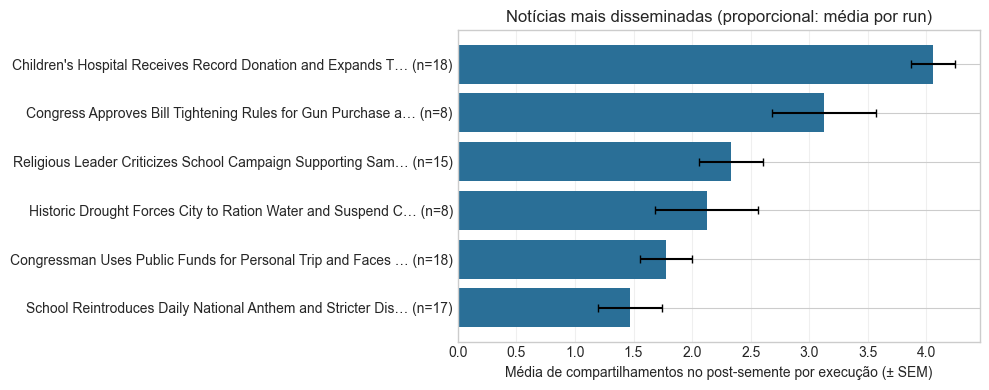

Salvo: D:\breno\Documents\TCC\Resultados\aggregated_all_batches\figures\01_news_dissemination.png


,news_topic_id,n_runs,total_seed_shares,mean_seed_shares,sem_seed_shares
3,hospital_donation,18,73,4.055556,0.189119
2,gun_law,8,25,3.125000,0.440677
4,religious_marriage,15,35,2.333333,0.270214
1,drought_climate,8,17,2.125000,0.440677
0,congress_corruption,18,32,1.777778,0.222222
5,school_anthem,17,25,1.470588,0.272753


In [8]:
# Gráfico 1: notícias mais disseminadas (média por run — proporcional ao nº de experimentos)
if df_runs_all.empty:
    print('Sem dados de sumário por run — gráfico 1 ignorado.')
else:
    news_agg = df_runs_all.groupby(['news_topic_id', 'news_title'], as_index=False).agg(
        total_seed_shares=('seed_shares', 'sum'),
        mean_seed_shares=('seed_shares', 'mean'),
        std_seed_shares=('seed_shares', 'std'),
        n_runs=('seed_shares', 'count'),
        mean_seed_replies=('seed_replies', 'mean'),
        mean_engagers=('unique_engagers_count', 'mean'),
    )
    news_agg['sem_seed_shares'] = news_agg['std_seed_shares'] / np.sqrt(
        news_agg['n_runs'].clip(lower=1)
    )
    news_agg = news_agg.sort_values('mean_seed_shares', ascending=True)

    fig, ax = plt.subplots(figsize=(10, max(4, 0.55 * len(news_agg))))
    y_labels = [
        f"{(row['news_title'][:58] + '…') if len(str(row['news_title'])) > 58 else row['news_title']} (n={int(row['n_runs'])})"
        for _, row in news_agg.iterrows()
    ]
    xerr = news_agg['sem_seed_shares'].fillna(0)
    ax.barh(y_labels, news_agg['mean_seed_shares'], xerr=xerr, capsize=3, color='#2a6f97')
    ax.set_xlabel('Média de compartilhamentos no post-semente por execução (± SEM)')
    ax.set_title('Notícias mais disseminadas (proporcional: média por run)')
    ax.grid(axis='x', alpha=0.3)
    fig.tight_layout()
    out_path = os.path.join(FIGURES_DIR, '01_news_dissemination.png')
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Salvo: {out_path}')
    display.display(
        news_agg.sort_values('mean_seed_shares', ascending=False)[
            ['news_topic_id', 'n_runs', 'total_seed_shares', 'mean_seed_shares', 'sem_seed_shares']
        ]
    )

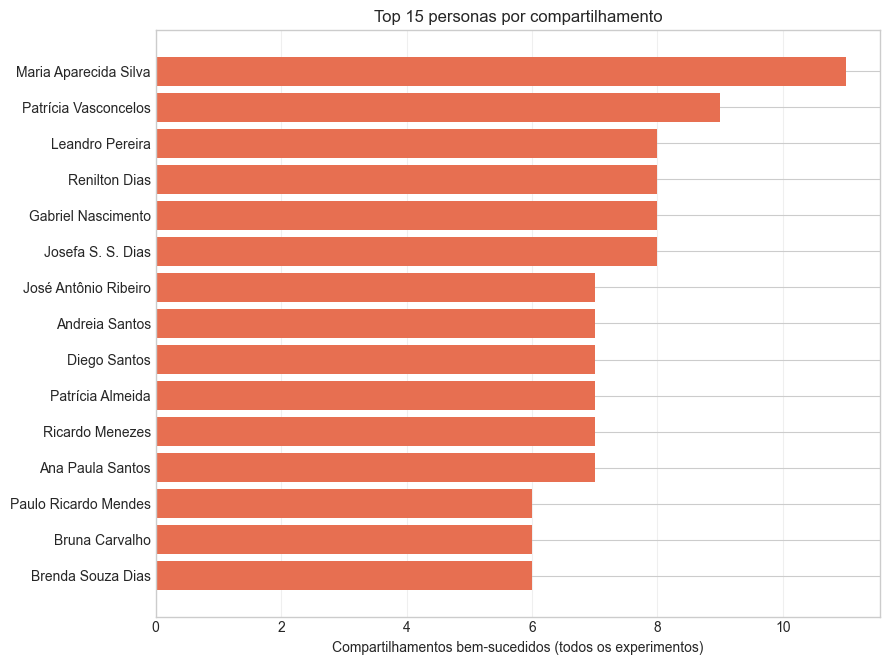

Salvo: D:\breno\Documents\TCC\Resultados\aggregated_all_batches\figures\02_persona_shares.png


,actor,successful_shares,total_actions,share_rate
26,Maria Aparecida Silva,11,83,0.132530
30,Patrícia Vasconcelos,9,62,0.145161
12,Gabriel Nascimento,8,101,0.079208
15,Josefa S. S. Dias,8,44,0.181818
21,Leandro Pereira,8,53,0.150943
34,Renilton Dias,8,44,0.181818
1,Ana Paula Santos,7,63,0.111111
29,Patrícia Almeida,7,82,0.085366
35,Ricardo Menezes,7,81,0.086420
16,José Antônio Ribeiro,7,56,0.125000


In [9]:
# Gráfico 2: personas que mais compartilharam posts
if df_actions_all.empty:
    print('Sem dados de ações — gráfico 2 ignorado.')
else:
    df_share = df_actions_all[
        df_actions_all['is_success']
        & df_actions_all['attempted_action_type'].eq('share')
    ]
    persona_shares = df_share.groupby('actor').size().reset_index(name='successful_shares')
    persona_totals = df_actions_all.groupby('actor').size().reset_index(name='total_actions')
    persona_plot = persona_shares.merge(persona_totals, on='actor', how='left')
    persona_plot['share_rate'] = (
        persona_plot['successful_shares'] / persona_plot['total_actions'].replace(0, np.nan)
    )
    persona_plot = persona_plot.sort_values('successful_shares', ascending=False)
    top_n = min(15, len(persona_plot))
    plot_df = persona_plot.head(top_n).sort_values('successful_shares', ascending=True)

    fig, ax = plt.subplots(figsize=(9, max(4, 0.45 * top_n)))
    ax.barh(plot_df['actor'], plot_df['successful_shares'], color='#e76f51')
    ax.set_xlabel('Compartilhamentos bem-sucedidos (todos os experimentos)')
    ax.set_title(f'Top {top_n} personas por compartilhamento')
    ax.grid(axis='x', alpha=0.3)
    fig.tight_layout()
    out_path = os.path.join(FIGURES_DIR, '02_persona_shares.png')
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Salvo: {out_path}')
    display.display(persona_plot.sort_values('successful_shares', ascending=False).head(20))

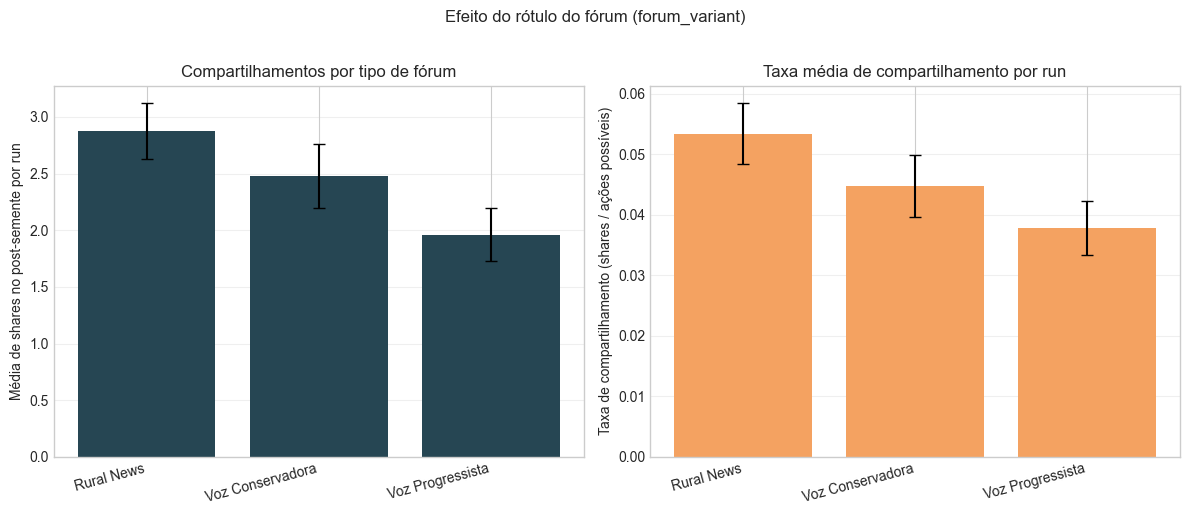

Salvo: D:\breno\Documents\TCC\Resultados\aggregated_all_batches\figures\03_forum_variant_sharing.png


,forum_variant,mean_seed_shares,std_seed_shares,mean_share_rate,std_share_rate,n_runs
0,Rural News,2.875000,1.385408,0.053437,0.028240,32
1,Voz Conservadora,2.480000,1.417745,0.044800,0.025515,25
2,Voz Progressista,1.962963,1.224163,0.037778,0.023094,27


Kruskal-Wallis (share_rate_run ~ forum_variant): H=5.922, p=0.0518


In [10]:
# Gráfico 3: influência do nome do fórum (forum_variant)
if df_runs_all.empty or 'forum_variant' not in df_runs_all.columns:
    print('Sem forum_variant nos sumários — gráfico 3 ignorado.')
else:
    forum_df = df_runs_all.dropna(subset=['forum_variant']).copy()
    try:
        forum_order = [f['name'] for f in FORUM_VARIANTS]
    except NameError:
        forum_order = sorted(forum_df['forum_variant'].dropna().unique())
    present = [f for f in forum_order if f in forum_df['forum_variant'].unique()]
    extra = sorted(set(forum_df['forum_variant'].unique()) - set(present))
    forum_order = present + extra

    forum_stats = forum_df.groupby('forum_variant').agg(
        mean_seed_shares=('seed_shares', 'mean'),
        std_seed_shares=('seed_shares', 'std'),
        mean_share_rate=('share_rate_run', 'mean'),
        std_share_rate=('share_rate_run', 'std'),
        n_runs=('seed_shares', 'count'),
    ).reindex(forum_order)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    x = np.arange(len(forum_order))
    w = 0.35

    sem_shares = forum_stats['std_seed_shares'].fillna(0) / np.sqrt(
        forum_stats['n_runs'].clip(lower=1)
    )
    axes[0].bar(
        x, forum_stats['mean_seed_shares'], yerr=sem_shares, capsize=4, color='#264653'
    )
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(forum_order, rotation=15, ha='right')
    axes[0].set_ylabel('Média de shares no post-semente por run')
    axes[0].set_title('Compartilhamentos por tipo de fórum')
    axes[0].grid(axis='y', alpha=0.3)

    sem_rate = forum_stats['std_share_rate'].fillna(0) / np.sqrt(
        forum_stats['n_runs'].clip(lower=1)
    )
    axes[1].bar(
        x, forum_stats['mean_share_rate'], yerr=sem_rate, capsize=4, color='#f4a261'
    )
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(forum_order, rotation=15, ha='right')
    axes[1].set_ylabel('Taxa de compartilhamento (shares / ações possíveis)')
    axes[1].set_title('Taxa média de compartilhamento por run')
    axes[1].grid(axis='y', alpha=0.3)

    fig.suptitle('Efeito do rótulo do fórum (forum_variant)', y=1.02)
    fig.tight_layout()
    out_path = os.path.join(FIGURES_DIR, '03_forum_variant_sharing.png')
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Salvo: {out_path}')
    display.display(forum_stats.reset_index())

    groups = [
        g['share_rate_run'].dropna().values
        for _, g in forum_df.groupby('forum_variant')
        if len(g) >= 2
    ]
    if len(groups) >= 2:
        h_stat, p_val = stats.kruskal(*groups)
        print(f'Kruskal-Wallis (share_rate_run ~ forum_variant): H={h_stat:.3f}, p={p_val:.4f}')

Correlação (n=84 runs): Pearson r=0.025 (p=0.8238), Spearman ρ=0.054 (p=0.6274)


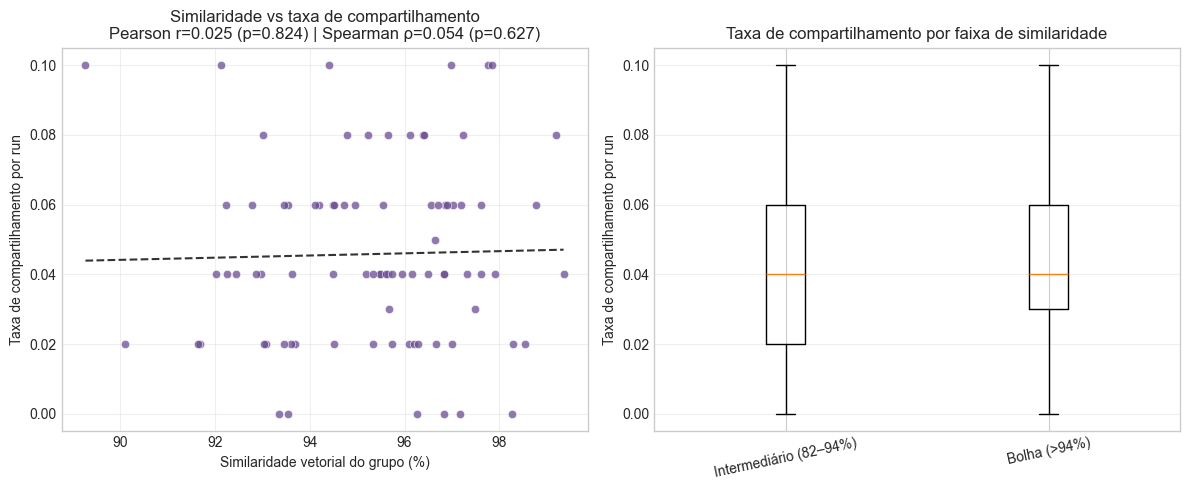

Salvo: D:\breno\Documents\TCC\Resultados\aggregated_all_batches\figures\04_similarity_vs_sharing.png


In [11]:
# Gráfico 4: similaridade do grupo vs taxa de compartilhamento
if df_runs_all.empty:
    print('Sem dados de sumário — gráfico 4 ignorado.')
else:
    sim_df = df_runs_all.dropna(subset=['group_cosine_similarity_pct']).copy()
    sim_df = sim_df.dropna(subset=['share_rate_run'])

    def _similarity_bin(pct):
        if pct < 82:
            return 'Polarizado (<82%)'
        if pct <= 94:
            return 'Intermediário (82–94%)'
        return 'Bolha (>94%)'

    sim_df['similarity_bin'] = sim_df['group_cosine_similarity_pct'].map(_similarity_bin)
    bin_order = ['Polarizado (<82%)', 'Intermediário (82–94%)', 'Bolha (>94%)']

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    if len(sim_df) >= 2:
        x = sim_df['group_cosine_similarity_pct'].values
        y = sim_df['share_rate_run'].values
        axes[0].scatter(x, y, alpha=0.75, color='#6a4c93', edgecolors='white', linewidths=0.5)
        if len(sim_df) >= 3:
            coef = np.polyfit(x, y, 1)
            x_line = np.linspace(x.min(), x.max(), 50)
            axes[0].plot(x_line, np.polyval(coef, x_line), '--', color='#333333', lw=1.5)
        pearson_r, pearson_p = stats.pearsonr(x, y)
        spearman_r, spearman_p = stats.spearmanr(x, y)
        axes[0].set_title(
            f'Similaridade vs taxa de compartilhamento\n'
            f'Pearson r={pearson_r:.3f} (p={pearson_p:.3f}) | '
            f'Spearman ρ={spearman_r:.3f} (p={spearman_p:.3f})'
        )
        print(
            f'Correlação (n={len(sim_df)} runs): '
            f'Pearson r={pearson_r:.3f} (p={pearson_p:.4f}), '
            f'Spearman ρ={spearman_r:.3f} (p={spearman_p:.4f})'
        )
    else:
        axes[0].set_title('Dados insuficientes para scatter')

    axes[0].set_xlabel('Similaridade vetorial do grupo (%)')
    axes[0].set_ylabel('Taxa de compartilhamento por run')
    axes[0].grid(alpha=0.3)

    box_data = [
        sim_df.loc[sim_df['similarity_bin'] == b, 'share_rate_run'].values
        for b in bin_order
        if b in sim_df['similarity_bin'].values
    ]
    box_labels = [b for b in bin_order if b in sim_df['similarity_bin'].values]
    if box_data:
        axes[1].boxplot(box_data, tick_labels=box_labels)
        axes[1].set_ylabel('Taxa de compartilhamento por run')
        axes[1].set_title('Taxa de compartilhamento por faixa de similaridade')
        axes[1].tick_params(axis='x', rotation=12)
        axes[1].grid(axis='y', alpha=0.3)
    else:
        axes[1].set_title('Sem faixas de similaridade')

    fig.tight_layout()
    out_path = os.path.join(FIGURES_DIR, '04_similarity_vs_sharing.png')
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Salvo: {out_path}')

In [12]:
instances = [
    prefab_lib.InstanceConfig(
        prefab='basic__Entity',
        role=prefab_lib.Role.ENTITY,
        params={
            'name': 'Oliver Cromwell',
            'goal': 'become lord protector',
        },
    ),
    prefab_lib.InstanceConfig(
        prefab='basic__Entity',
        role=prefab_lib.Role.ENTITY,
        params={
            'name': 'King Charles I',
            'goal': 'avoid execution for treason',
        },
    ),
    prefab_lib.InstanceConfig(
        prefab='generic__GameMaster',
        role=prefab_lib.Role.GAME_MASTER,
        params={
            'name': 'default rules',
            'extra_event_resolution_steps': '',
        },
    ),
    prefab_lib.InstanceConfig(
        prefab='formative_memories_initializer__GameMaster',
        role=prefab_lib.Role.INITIALIZER,
        params={
            'name': 'initial setup rules',
            'next_game_master_name': 'default rules',
            'shared_memories': [
                'The king was captured by Parliamentary forces in 1646.',
                'Charles I was tried for treason and found guilty.',
            ],
        },
    ),
]

In [13]:
import inspect
assinatura = inspect.signature(asynchronous.Asynchronous.__init__)
print(f"O Motor Assíncrono exige estes parâmetros: {assinatura}")

O Motor Assíncrono exige estes parâmetros: (self, call_to_make_observation: str = 'What is the current situation faced by {name}? What do they now observe? Only include information of which they are aware.', call_to_next_acting: str = 'Which entities act next?', call_to_next_action_spec: str = 'In what action spec format should {name} respond? Respond in  one of the provided formats and use no additional words.', call_to_resolve: str = 'Because of all that came before, what happens next?', call_to_check_termination: str = 'Is the game/simulation finished?', call_to_next_game_master: str = 'Which rule set should we use for the next step?', sleep_time: float = 0.1)
